# Keith Wampler
# 569 Spring 2026
# Homework 2

Assignment:

(1) Load the Iris data set.

(2) Perform a logistic regression on whether or not the data point is setosa.

(3) Apply a neural network in either PyTorch or TensorFlow using:

(a) Sigmoid activation function, and
(b) ReLU activation function.

In [1]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)

df['is_setosa'] = (iris.target == 0).astype(int)

print(df.head())
print("\nTarget distribution (1 - setosa, 0 - not setosa):")
print(df['is_setosa'].value_counts(normalize=True))

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   is_setosa  
0          1  
1          1  
2          1  
3          1  
4          1  

Target distribution (1 - setosa, 0 - not setosa):
is_setosa
0    0.666667
1    0.333333
Name: proportion, dtype: float64


Accuracy: 100.00%
Weights (Coefficients): [[-0.4276806   0.89079469 -2.21885572 -0.91197889]]
Bias (Intercept): [6.26970945]


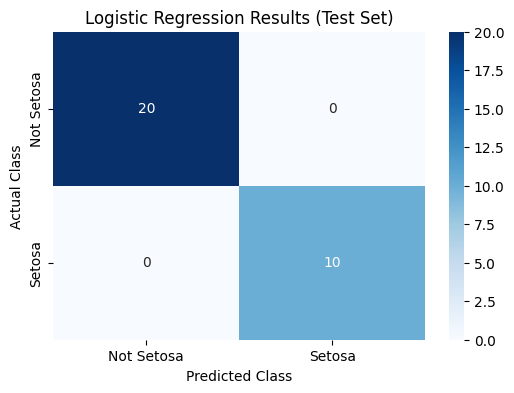

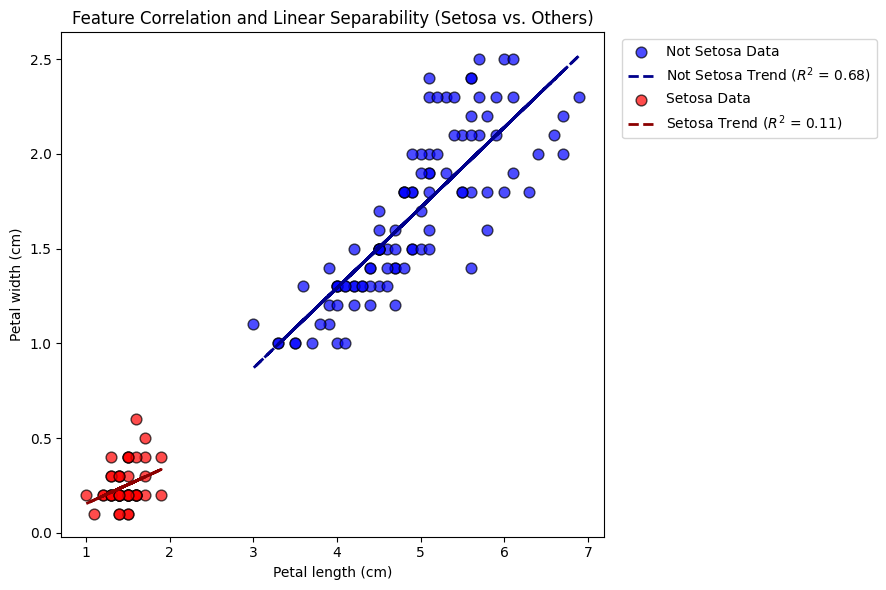

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix


X = iris.data
Y = df['is_setosa']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1701, stratify=Y)


log_reg = LogisticRegression()
log_reg.fit(X_train, Y_train)
predictions = log_reg.predict(X_test)


accuracy = accuracy_score(Y_test, predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Weights (Coefficients): {log_reg.coef_}")
print(f"Bias (Intercept): {log_reg.intercept_}")


cm = confusion_matrix(Y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Setosa', 'Setosa'], 
            yticklabels=['Not Setosa', 'Setosa'])
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.title('Logistic Regression Results (Test Set)')
plt.show()


plt.figure(figsize=(9, 6))

petal_length = X[:, 2]
petal_width = X[:, 3]

mask_not_setosa = (Y == 0)
x_not_setosa = petal_length[mask_not_setosa]
y_not_setosa = petal_width[mask_not_setosa]

plt.scatter(x_not_setosa, y_not_setosa, color='blue', edgecolors='k', s=60, alpha=0.7, label='Not Setosa Data')

slope0, intercept0, r_value0, p_value0, std_err0 = linregress(x_not_setosa, y_not_setosa)
r_squared0 = r_value0**2
plt.plot(x_not_setosa, slope0 * x_not_setosa + intercept0, color='darkblue', linestyle='--', linewidth=2,
         label=f'Not Setosa Trend ($R^2$ = {r_squared0:.2f})')

mask_setosa = (Y == 1)
x_setosa = petal_length[mask_setosa]
y_setosa = petal_width[mask_setosa]

plt.scatter(x_setosa, y_setosa, color='red', edgecolors='k', s=60, alpha=0.7, label='Setosa Data')

slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x_setosa, y_setosa)
r_squared1 = r_value1**2
plt.plot(x_setosa, slope1 * x_setosa + intercept1, color='darkred', linestyle='--', linewidth=2,
         label=f'Setosa Trend ($R^2$ = {r_squared1:.2f})')

plt.xlabel(iris.feature_names[2].capitalize())
plt.ylabel(iris.feature_names[3].capitalize())
plt.title('Feature Correlation and Linear Separability (Setosa vs. Others)')

plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

Results for Sigmoid Neural Network:
Final Training Loss: 0.0045
Test Set Accuracy: 100.00%


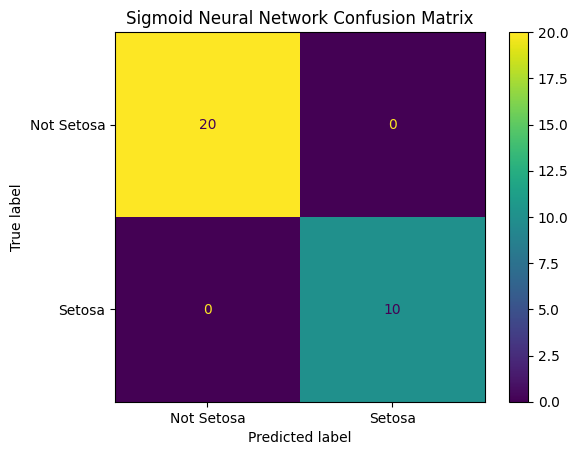


Results for ReLU Neural Network:
Final Training Loss: 0.0001
Test Set Accuracy: 100.00%


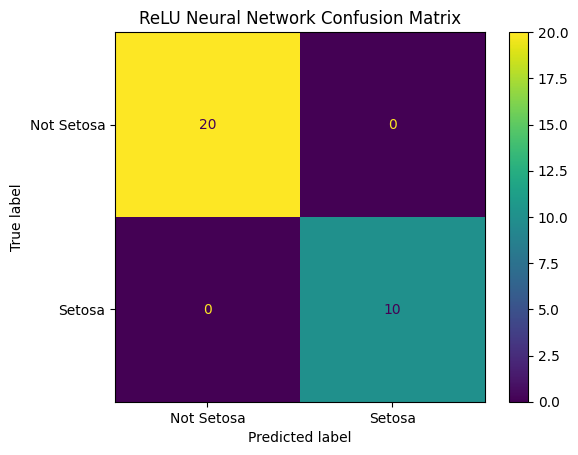

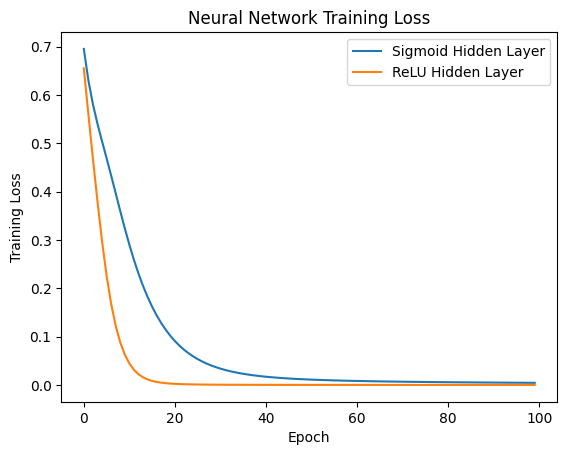

In [6]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

iris = load_iris()

X = iris.data
Y = (iris.target == 0).astype(int)

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=1701,
    stratify=Y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32).view(-1, 1)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32).view(-1, 1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_tensor = X_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
Y_train_tensor = Y_train_tensor.to(device)
Y_test_tensor = Y_test_tensor.to(device)


class IrisNet(nn.Module):
    def __init__(self, activation_function):
        super(IrisNet, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(4, 8),
            activation_function,
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


def train_and_evaluate_with_confusion_matrix(activation_function, model_name):
    torch.manual_seed(1701)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(1701)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    model = IrisNet(activation_function).to(device)

    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.05)

    loss_history = []
    epochs = 100

    for epoch in range(epochs):
        optimizer.zero_grad()

        outputs = model(X_train_tensor)
        loss = criterion(outputs, Y_train_tensor)

        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

    with torch.no_grad():
        probabilities = model(X_test_tensor)
        predicted_classes = (probabilities >= 0.5).float()

        accuracy = (
            (predicted_classes == Y_test_tensor).sum().item()
            / Y_test_tensor.shape[0]
        )

    print(f"Results for {model_name} Neural Network:")
    print(f"Final Training Loss: {loss_history[-1]:.4f}")
    print(f"Test Set Accuracy: {accuracy * 100:.2f}%")

    y_true = Y_test_tensor.cpu().numpy()
    y_pred = predicted_classes.cpu().numpy()

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Setosa", "Setosa"]
    )

    disp.plot()
    plt.title(f"{model_name} Neural Network Confusion Matrix")
    plt.show()

    print()

    return loss_history


sigmoid_losses = train_and_evaluate_with_confusion_matrix(
    nn.Sigmoid(),
    "Sigmoid"
)

relu_losses = train_and_evaluate_with_confusion_matrix(
    nn.ReLU(),
    "ReLU"
)

plt.plot(sigmoid_losses, label="Sigmoid Hidden Layer")
plt.plot(relu_losses, label="ReLU Hidden Layer")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Neural Network Training Loss")
plt.legend()
plt.show()

While the Sigmoid function is excellent for final classification layers because it neatly compresses outputs into a probability between 0 and 1, it struggles in hidden layers due to the vanishing gradient problem. The mathematical extremes of the Sigmoid curve are flat, which creates incredibly small derivatives. When the neural network multiplies these tiny gradients backward, the learning process stalls. 

To solve that bottleneck, the ReLU has become the standard for hidden layers. By outputting the exact input for positive numbers and zero for negative numbers, the ReLU activation maintains a constant derivative of 1 for all positive values. This constant derivative prevents gradients from vanishing, which allows deep networks to converge rapidly. The computational efficiency of the ReLU function makes it the preferred choice for optimizing modern models.

In this iris classification task, both activation functions achieved perfect test accuracy, but the ReLU model converged faster and reached a lower training loss.